In [1]:
import pandas as pd

df_final_scaled = pd.read_csv("FAIDM/final_all_scaled.csv")
df_final_scaled.head()


,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,num_of_prev_attempts,studied_credits,imd_band_clean,...,has_early_access,click_Active_Study,click_Content,click_Nav,click_Social,active_days_Active_Study,active_days_Content,active_days_Nav,active_days_Social,final_result
0,1,0,0,0,0,0,0,-0.332952,4.263825,1.604060,...,1.0,-0.559876,0.101785,-0.494583,-0.232970,-0.887462,-0.474815,-0.520408,-0.348189,Pass
1,1,0,0,0,0,0,0,-0.332952,-0.438086,-0.636140,...,1.0,-0.559876,0.138125,0.026603,0.108528,-0.887462,0.120836,0.248438,0.291735,Pass
2,1,0,0,0,0,0,0,-0.332952,-0.438086,0.323946,...,1.0,-0.559876,0.624520,0.383431,0.439354,-0.887462,1.285063,1.036505,0.931660,Pass
3,1,0,0,0,0,0,0,-0.332952,-0.438086,0.323946,...,1.0,-0.559876,0.076627,-0.250210,-0.231445,-0.887462,0.418662,0.017784,-0.200514,Pass
4,1,0,0,0,0,0,0,-0.332952,-0.438086,1.284031,...,1.0,-0.559876,0.639895,0.441821,0.806768,-0.887462,0.635262,1.440149,1.473134,Pass


In [2]:
# Core numerical + data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Rich notebook display
from IPython.display import display

# Train/test splitting and CV helpers
from sklearn.model_selection import train_test_split, StratifiedKFold

# Pipelines
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression

# Feature selection
from sklearn.feature_selection import RFE, RFECV

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [3]:
# Features and target
X = df_final_scaled.drop(columns=["final_result"])
y = df_final_scaled["final_result"].map({
    "Withdrawn": 0,
    "Fail": 1,
    "Pass": 2,
    "Distinction": 2
}).astype(int)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
display(y.value_counts())


Feature matrix shape: (25783, 44)
Target distribution:


final_result
2    15377
1     5739
0     4667
Name: count, dtype: int64

In [4]:
display(X.describe().T)


,count,mean,std,min,25%,50%,75%,max
code_module_AAA,25783.0,2.734360e-02,0.163086,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_BBB,25783.0,2.346120e-01,0.423764,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_CCC,25783.0,1.322577e-01,0.338777,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_DDD,25783.0,1.910949e-01,0.393171,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_EEE,25783.0,8.905093e-02,0.284823,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_FFF,25783.0,2.438428e-01,0.429407,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_GGG,25783.0,8.179808e-02,0.274062,0.000000,0.000000,0.000000,0.000000,1.000000
num_of_prev_attempts,25783.0,-1.543280e-17,1.000019,-0.332952,-0.332952,-0.332952,-0.332952,12.556700
studied_credits,25783.0,4.409372e-17,1.000019,-1.221738,-0.438086,-0.438086,0.345566,14.451299
imd_band_clean,25783.0,3.086560e-17,1.000019,-1.468214,-0.636140,0.003917,0.964003,1.604060


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)


Train shape: (19337, 44)
Test shape:  (6446, 44)


In [6]:
baseline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])

baseline.fit(X_train, y_train)

pred_base = baseline.predict(X_test)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, pred_base),
    "Macro F1": f1_score(y_test, pred_base, average="macro")
}

baseline_metrics


{'Accuracy': 0.7908780639156066, 'Macro F1': 0.6939988673270551}

,feature,mean_abs_coef
23,total_attempt_ratio,1.168859
34,active_weeks,0.768906
25,attempted_core_score,0.720019
26,core_completion_ratio,0.718859
24,performance_efficiency,0.477512
6,code_module_GGG,0.351125
42,active_days_Nav,0.248649
33,active_days,0.237541
5,code_module_FFF,0.202268
27,attempted_optional_score,0.200861


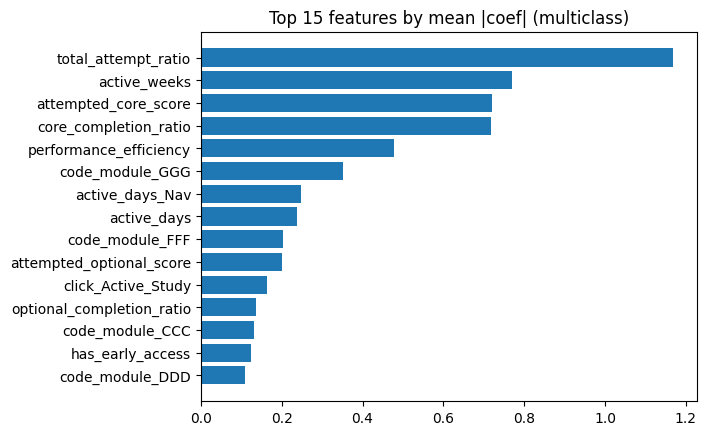

In [7]:
# For multinomial LR: coef_ shape = (n_classes, n_features)
coefs = np.mean(np.abs(baseline.named_steps["model"].coef_), axis=0)

importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_coef": coefs
}).sort_values("mean_abs_coef", ascending=False)

display(importance.head(15))

# Plot top 15
top = importance.head(15).sort_values("mean_abs_coef")
plt.barh(top["feature"], top["mean_abs_coef"])
plt.title("Top 15 features by mean |coef| (multiclass)")
plt.show()


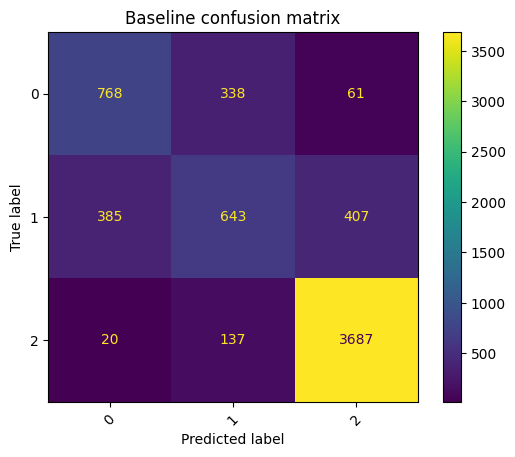

In [8]:
cm = confusion_matrix(y_test, pred_base)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline.named_steps["model"].classes_
)

disp.plot(xticks_rotation=45)
plt.title("Baseline confusion matrix")
plt.show()


In [9]:
rfe_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("select", RFE(
        estimator=LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            random_state=42
        ),
        n_features_to_select=10,
        step=1
    )),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])

rfe_pipeline.fit(X_train, y_train)

pred_rfe = rfe_pipeline.predict(X_test)

rfe_metrics = {
    "Accuracy": accuracy_score(y_test, pred_rfe),
    "Macro F1": f1_score(y_test, pred_rfe, average="macro")
}

rfe_metrics


{'Accuracy': 0.773968352466646, 'Macro F1': 0.6653611492280639}

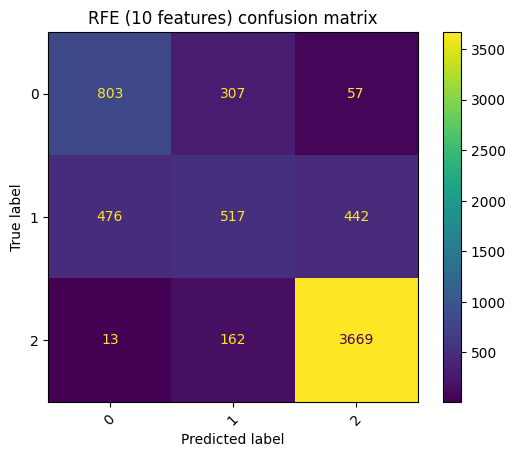

In [10]:
cm = confusion_matrix(y_test, pred_rfe)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rfe_pipeline.named_steps["model"].classes_
)

disp.plot(xticks_rotation=45)
plt.title("RFE (10 features) confusion matrix")
plt.show()


In [11]:
comparison = pd.DataFrame(
    [baseline_metrics, rfe_metrics],
    index=["Baseline (all features)", "RFE (10 features)"]
)

display(comparison)


,Accuracy,Macro F1
Baseline (all features),0.790878,0.693999
RFE (10 features),0.773968,0.665361


In [12]:
selector = rfe_pipeline.named_steps["select"]

ranking_df = pd.DataFrame({
    "feature": X.columns,
    "rank": selector.ranking_,
    "selected": selector.support_
}).sort_values(["rank", "feature"])

display(ranking_df)


,feature,rank,selected
33,active_days,1,True
42,active_days_Nav,1,True
34,active_weeks,1,True
25,attempted_core_score,1,True
36,click_Active_Study,1,True
1,code_module_BBB,1,True
6,code_module_GGG,1,True
26,core_completion_ratio,1,True
24,performance_efficiency,1,True
23,total_attempt_ratio,1,True


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("select", RFECV(
        estimator=LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            random_state=42
        ),
        step=1,
        cv=cv,
        scoring="f1_macro",
        min_features_to_select=5
    )),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])

rfecv_pipeline.fit(X_train, y_train)

pred_rfecv = rfecv_pipeline.predict(X_test)

rfecv_metrics = {
    "Accuracy": accuracy_score(y_test, pred_rfecv),
    "Macro F1": f1_score(y_test, pred_rfecv, average="macro")
}

rfecv_metrics


{'Accuracy': 0.7908780639156066, 'Macro F1': 0.6939988673270551}

Optimal number of features (by CV): 44
Number of selected features: 44
Number of removed features: 0

Selected features:
  ✓ code_module_AAA
  ✓ code_module_BBB
  ✓ code_module_CCC
  ✓ code_module_DDD
  ✓ code_module_EEE
  ✓ code_module_FFF
  ✓ code_module_GGG
  ✓ num_of_prev_attempts
  ✓ studied_credits
  ✓ imd_band_clean
  ✓ age_band_clean
  ✓ edu_clean_A_Level
  ✓ edu_clean_Below_A_Level
  ✓ edu_clean_Higher_Ed
  ✓ edu_clean_No_Formal
  ✓ edu_clean_Post_Grad
  ✓ region_clean_Devolved_Ireland
  ✓ region_clean_London
  ✓ region_clean_Midlands_East
  ✓ region_clean_North
  ✓ region_clean_South
  ✓ gender_M
  ✓ disability_Y
  ✓ total_attempt_ratio
  ✓ performance_efficiency
  ✓ attempted_core_score
  ✓ core_completion_ratio
  ✓ attempted_optional_score
  ✓ optional_completion_ratio
  ✓ has_banked_score
  ✓ avg_submission_gap
  ✓ is_early_submitter
  ✓ total_clicks
  ✓ active_days
  ✓ active_weeks
  ✓ has_early_access
  ✓ click_Active_Study
  ✓ click_Content
  ✓ click_Nav
  ✓ click_Socia

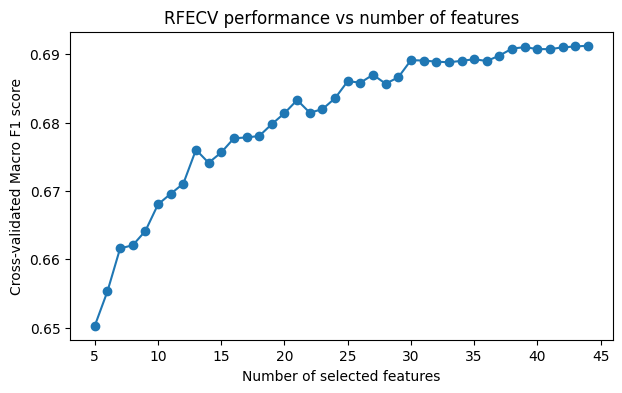

In [14]:
# Extract RFECV results and plot CV score vs number of selected features
rfecv_selector = rfecv_pipeline.named_steps["select"]

print("Optimal number of features (by CV):", rfecv_selector.n_features_)

# Selected features
selected_features = X.columns[rfecv_selector.support_].tolist()

# Removed (not selected) features
removed_features = X.columns[~rfecv_selector.support_].tolist()

print(f"Number of selected features: {len(selected_features)}")
print(f"Number of removed features: {len(removed_features)}")

print("\nSelected features:")
for f in selected_features:
    print(f"  ✓ {f}")

print("\nRemoved (not selected) features:")
for f in removed_features:
    print(f"  ✗ {f}")
# scikit-learn stores RFECV scores differently across versions
scores = None
n_features = None

if hasattr(rfecv_selector, "cv_results_") and "mean_test_score" in rfecv_selector.cv_results_:
    scores = rfecv_selector.cv_results_["mean_test_score"]
    n_features = rfecv_selector.cv_results_["n_features"]
elif hasattr(rfecv_selector, "grid_scores_"):
    scores = rfecv_selector.grid_scores_
    n_features = np.arange(1, len(scores) + 1)

plt.figure(figsize=(7, 4))
plt.plot(n_features, scores, marker="o")
plt.xlabel("Number of selected features")
plt.ylabel("Cross-validated Macro F1 score")
plt.title("RFECV performance vs number of features")
plt.show()


In [15]:
final_comparison = pd.DataFrame(
    [baseline_metrics, rfe_metrics, rfecv_metrics],
    index=["Baseline", "RFE (10)", "RFECV (auto)"]
)

display(final_comparison)


,Accuracy,Macro F1
Baseline,0.790878,0.693999
RFE (10),0.773968,0.665361
RFECV (auto),0.790878,0.693999


In [17]:

X_final_scaled = df_final_scaled.drop(columns=["final_result"])
y_final = df_final_scaled["final_result"]


X_selected_final = X_final_scaled[selected_features]


final_selected_with_target = pd.concat(
    [X_selected_final, y_final],
    axis=1
)

In [18]:
final_selected_with_target.to_csv(
    "FAIDM/final_selected_scaled.csv",
    index=False
)